In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem, FindMolChiralCenters
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import shap


In [2]:
# Cell 2: Basic Features Model (with epimerisable‐centre flag)
# 1) Load & label data
df_basic = (
    pd.read_csv("M:/EPSRC Internship 2025/Project/Data/Classification Model/epimerisation_data_clean.csv",
                usecols=['epimerisation','smilesstarting_material'])
      .rename(columns={'smilesstarting_material':'smi_start'})
)
y_basic = df_basic['epimerisation'].astype(int)

# 2) Descriptor functions
def compute_rdkit(smiles):
    cols = [n for n,_ in Descriptors._descList]
    data = []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        data.append([f(m) if m else np.nan for _,f in Descriptors._descList])
    return pd.DataFrame(data, columns=cols)

def compute_morgan(smiles, radius=2, n_bits=1024):
    fps, dens = [], []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        arr = np.zeros((n_bits,), dtype=int)
        if m:
            fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
            DataStructs.ConvertToNumpyArray(fp, arr)
            dens.append(arr.sum()/n_bits)
        else:
            dens.append(np.nan)
        fps.append(arr)
    cols = [f"FP_{i}" for i in range(n_bits)]
    df_fp = pd.DataFrame(fps, columns=cols)
    df_fp['FP_density'] = dens
    return df_fp

def has_epimerisable_center(smi):
    m = Chem.MolFromSmiles(smi)
    if not m: return 0
    centers = FindMolChiralCenters(m, includeUnassigned=True)
    for idx,_ in centers:
        atom = m.GetAtomWithIdx(idx)
        if atom.GetTotalNumHs() > 0:
            return 1
    return 0

# 3) Build feature matrix
X_basic = pd.concat([
    compute_rdkit(df_basic.smi_start),
    compute_morgan(df_basic.smi_start),
    df_basic.smi_start.map(has_epimerisable_center).rename("has_center")
], axis=1)
mask = X_basic.notna().all(axis=1)
X_basic, y_basic = X_basic[mask], y_basic[mask]

# 4) Train/test split & pipeline
SEED = 42
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_basic, y_basic,
                                                  test_size=0.2,
                                                  stratify=y_basic,
                                                  random_state=SEED)

class CorrFilter(BaseEstimator, TransformerMixin):
    def __init__(self, thresh=0.9, feature_names=None):
        self.thresh = thresh
        self.feature_names = feature_names
    def fit(self, X, y=None):
        C = pd.DataFrame(X, columns=self.feature_names).corr().abs()
        U = C.where(np.triu(np.ones(C.shape),1).astype(bool))
        drop = [c for c in U if any(U[c]>self.thresh)]
        self.keep = [i for i,f in enumerate(self.feature_names) if f not in drop]
        return self
    def transform(self, X):
        return X[:, self.keep]

feat_names_basic = X_tr_b.columns.tolist()
pipe_basic = ImbPipeline([
    ("imp", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("corr", CorrFilter(thresh=0.9, feature_names=feat_names_basic)),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=SEED))
])
param_dist = {
    "clf__n_estimators": [100,200,300],
    "clf__max_depth": [None,10,20],
    "clf__min_samples_split": [2,5,10]
}
rs_basic = RandomizedSearchCV(pipe_basic, param_dist, n_iter=20,
                              scoring="precision", cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                              random_state=SEED, n_jobs=-1)
rs_basic.fit(X_tr_b.values, y_tr_b)
best_basic = rs_basic.best_estimator_


[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerator
[12:41:52] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
# %% Cell 3: Basic Features Model - Accurate Predictions with Full Display

# Load data
novel = pd.read_csv(
    r"M:\EPSRC Internship 2025\Project\Data\Novel\Data\Copy of Epimerisation - novel compounds to test.csv"
)
novel.rename(
    columns={novel.columns[0]: 'Entry_ID', novel.columns[1]: 'smi_start'},
    inplace=True
)

# 1) Compute features
novel["has_center"] = novel["smi_start"].apply(has_epimerisable_center)
Xn_basic = pd.concat([
    compute_rdkit(novel["smi_start"]),
    compute_morgan(novel["smi_start"]),
    novel[["has_center"]]
], axis=1)

for c in feat_names_basic:
    if c not in Xn_basic.columns:
        Xn_basic[c] = 0
Xn_basic = Xn_basic[feat_names_basic]

# 2) Get raw predictions
novel["prob_raw"] = best_basic.predict_proba(Xn_basic.values)[:, 1]

# 3) Use raw probabilities for accuracy
mask_epimerizable = novel["has_center"] == 1
novel["Epimerization_Probability"] = novel["prob_raw"]
novel.loc[~mask_epimerizable, "Epimerization_Probability"] = np.nan

# 4) Analyze prediction distribution
epi_probs = novel.loc[mask_epimerizable, "Epimerization_Probability"]
print("🔍 Basic Features Model - Prediction Analysis:")
print(f"  Probability range: {epi_probs.min():.4f} - {epi_probs.max():.4f}")
print(f"  Mean: {epi_probs.mean():.4f}, Std: {epi_probs.std():.4f}")
print(f"  Predictions < 0.3: {(epi_probs < 0.3).sum()}")
print(f"  Predictions 0.3-0.7: {((epi_probs >= 0.3) & (epi_probs <= 0.7)).sum()}")
print(f"  Predictions > 0.7: {(epi_probs > 0.7).sum()}")

# 5) Create predictions
novel["Epimerizes"] = "N/A"
novel.loc[mask_epimerizable, "Epimerizes"] = (
    novel.loc[mask_epimerizable, "Epimerization_Probability"] >= 0.5
).map({True: "Yes", False: "No"})

# 6) Create output dataframe
output_df = pd.DataFrame({
    "Entry_ID": novel["Entry_ID"],
    "SMILES": novel["smi_start"],
    "Epimerization_Probability": novel["Epimerization_Probability"],
    "Epimerizes": novel["Epimerizes"]
})

# 7) Save to CSV
output_df[["Entry_ID", "Epimerization_Probability", "Epimerizes"]].to_csv(
    "epimerization_predictions_basic.csv", index=False
)
print(f"✅ Saved predictions to 'epimerization_predictions_basic.csv'")

# 8) Create HTML display for ALL entries
def format_probability(val):
    if pd.isna(val):
        return '<span style="color: #95a5a6;">N/A</span>'
    color = f"rgb({int(255*val)}, {int(255*(1-val))}, 0)"
    return f'<span style="color: {color}; font-weight: bold;">{val:.4f}</span>'

def format_epimerizes(val):
    if val == "Yes":
        return '<span style="color: #e74c3c; font-weight: bold;">Yes</span>'
    elif val == "No":
        return '<span style="color: #27ae60; font-weight: bold;">No</span>'
    else:
        return '<span style="color: #95a5a6;">N/A</span>'

# Apply formatting
html_df = output_df.copy()
html_df["Epimerization_Probability"] = html_df["Epimerization_Probability"].apply(format_probability)
html_df["Epimerizes"] = html_df["Epimerizes"].apply(format_epimerizes)
html_df["SMILES"] = html_df["SMILES"].apply(lambda x: f'<span style="font-family: monospace; font-size: 11px;">{x}</span>')

# Create HTML
html_table = html_df.to_html(index=False, escape=False)

styled_html = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif;">
    <h2 style="color: #2c3e50; margin-bottom: 10px;">
        Epimerization Predictions - Basic Features Model (All {len(output_df)} Compounds)
    </h2>
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
        <p style="margin: 0; font-size: 14px;">
            <strong>Model:</strong> Basic Features (RDKit Descriptors + Morgan Fingerprints + Has H at Chiral Center)<br>
            <strong>Probability Range:</strong> {epi_probs.min():.4f} - {epi_probs.max():.4f}<br>
            <strong>Epimerizable:</strong> {mask_epimerizable.sum()} | 
            <strong>Non-epimerizable:</strong> {(~mask_epimerizable).sum()}<br>
            <strong>Predicted Yes:</strong> {(output_df['Epimerizes'] == 'Yes').sum()} | 
            <strong>Predicted No:</strong> {(output_df['Epimerizes'] == 'No').sum()}
        </p>
    </div>
    <div style="max-height: 600px; overflow-y: auto; border: 2px solid #3498db; border-radius: 5px;">
        <style>
            .basic-table {{
                border-collapse: collapse;
                width: 100%;
                font-size: 13px;
            }}
            .basic-table th {{
                background-color: #3498db;
                color: white;
                padding: 12px 8px;
                position: sticky;
                top: 0;
                z-index: 10;
                text-align: left;
            }}
            .basic-table td {{
                padding: 8px;
                border-bottom: 1px solid #ecf0f1;
            }}
            .basic-table tr:hover {{
                background-color: #e8f6f9;
            }}
            .basic-table tr:nth-child(even) {{
                background-color: #f8f9fa;
            }}
        </style>
        <table class="basic-table">
            {html_table.replace('<table', '').replace('</table>', '')}
        </table>
    </div>
    <p style="margin-top: 10px; font-size: 12px; color: #7f8c8d;">
        <em>Note: These are raw model probabilities without artificial expansion. 
        Color scale: <span style="color: rgb(0,255,0);">Low risk</span> → 
        <span style="color: rgb(255,255,0);">Medium</span> → 
        <span style="color: rgb(255,0,0);">High risk</span></em>
    </p>
</div>
"""

display(HTML(styled_html))

# 9) Show extremes
if mask_epimerizable.sum() > 0:
    epi_df = output_df[output_df['Epimerizes'] != 'N/A'].copy()
    epi_df['prob_numeric'] = novel.loc[mask_epimerizable, 'Epimerization_Probability']
    
    highest = epi_df.loc[epi_df['prob_numeric'].idxmax()]
    lowest = epi_df.loc[epi_df['prob_numeric'].idxmin()]
    
    print(f"\n🔴 Highest risk: {highest['Entry_ID']} (p={highest['prob_numeric']:.4f})")
    print(f"🟢 Lowest risk: {lowest['Entry_ID']} (p={lowest['prob_numeric']:.4f})")

# 10) Compare with metadata model if available
try:
    meta_probs = pd.read_csv("epimerization_predictions_metadata.csv")
    comparison = pd.merge(
        output_df[["Entry_ID", "Epimerization_Probability"]],
        meta_probs[["Entry_ID", "Epimerization_Probability"]],
        on="Entry_ID",
        suffixes=("_basic", "_meta")
    )
    
    # Calculate differences for epimerizable compounds
    epi_comparison = comparison[~comparison["Epimerization_Probability_basic"].isna()]
    epi_comparison["diff"] = abs(epi_comparison["Epimerization_Probability_basic"] - 
                                  epi_comparison["Epimerization_Probability_meta"])
    
    print(f"\n📊 Model Comparison (Basic vs Metadata):")
    print(f"  Mean absolute difference: {epi_comparison['diff'].mean():.4f}")
    print(f"  Max difference: {epi_comparison['diff'].max():.4f}")
    print(f"  Agreement on classification: {(epi_comparison['Epimerization_Probability_basic'] >= 0.5).eq(epi_comparison['Epimerization_Probability_meta'] >= 0.5).sum()}/{len(epi_comparison)} compounds")
    
except:
    print("\n(Run metadata model to see comparison)")

[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerator
[14:08:58] DEPRECATION WARNING: please use MorganGenerat

🔍 Basic Features Model - Prediction Analysis:
  Probability range: 0.4991 - 0.9519
  Mean: 0.7230, Std: 0.0980
  Predictions < 0.3: 0
  Predictions 0.3-0.7: 107
  Predictions > 0.7: 157
✅ Saved predictions to 'epimerization_predictions_basic.csv'


Entry_ID,SMILES,Epimerization_Probability,Epimerizes
LCC_EPIM_001,COC([C@@H](C1)NCCC1(F)F)=O,0.7172,Yes
LCC_EPIM_002,C[C@@H](CC1)NC[C@@H]1C(OC)=O.Cl,0.8408,Yes
LCC_EPIM_003,C[C@@H](C1)NCC[C@@H]1C(OC)=O.Cl,0.8151,Yes
LCC_EPIM_004,C[C@H](C1)NCC[C@H]1C(OC)=O.Cl,0.8151,Yes
LCC_EPIM_005,CCOC(C[C@H]1NCCCC1)=O.Cl,0.6951,Yes
LCC_EPIM_006,Nc1ccc([C@H]2CNCCC2)cc1,0.7073,Yes
LCC_EPIM_007,Brc1ccc([C@@H]2CNCCC2)cc1,0.7802,Yes
LCC_EPIM_008,Brc1ccc([C@H]2CNCCC2)cc1,0.7802,Yes
LCC_EPIM_009,C[C@@H](C1)NCCN1C(OC(C)(C)C)=O,0.6813,Yes
LCC_EPIM_010,C[C@@H](CNCC1)N1C(OC(C)(C)C)=O,0.6724,Yes



🔴 Highest risk: LCC_EPIM_262 (p=0.9519)
🟢 Lowest risk: LCC_EPIM_099 (p=0.4991)

📊 Model Comparison (Basic vs Metadata):
  Mean absolute difference: 0.0391
  Max difference: 0.1462
  Agreement on classification: 260/264 compounds


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_6200\3030681666.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epi_comparison["diff"] = abs(epi_comparison["Epimerization_Probability_basic"] -


In [13]:
# %%  Cell 4: Pre-Reaction Metadata Model (with epimerisable-centre flag)
# 1) Load & prepare
df_meta = pd.read_csv(
    "M:/EPSRC Internship 2025/Project/Data/Classification Model/epimerisation_data_clean.csv",
    usecols=[
        'epimerisation','smilesstarting_material',
        'conditions','reaction_class','substrate_class',
        'derivative_notes','specific_reagents',
        'solvent_1','solvent_2','temperature_C','reaction_time_h'
    ]
).rename(columns={'smilesstarting_material':'smi_start'})
y_meta = df_meta.epimerisation.astype(int)

# 2) compute same chemical features + metadata
rd_df = compute_rdkit(df_meta.smi_start)
mo_df = compute_morgan(df_meta.smi_start)
meta_cat = df_meta[[ 'conditions','reaction_class','substrate_class',
                     'derivative_notes','specific_reagents',
                     'solvent_1','solvent_2']].fillna('Missing')
meta_cat = pd.get_dummies(meta_cat, drop_first=False)
meta_num = df_meta[['temperature_C','reaction_time_h']].fillna(method='ffill')
flag = df_meta.smi_start.map(has_epimerisable_center).rename("has_center")

X_meta = pd.concat([rd_df, mo_df, meta_cat, meta_num, flag], axis=1)
mask = X_meta.notna().all(axis=1)
X_meta, y_meta = X_meta[mask], y_meta[mask]

# 3) train/test & pipeline (reuse CorrFilter)
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_meta, y_meta,
                                                  test_size=0.2,
                                                  stratify=y_meta,
                                                  random_state=SEED)

feat_names_meta = X_tr_m.columns.tolist()
pipe_meta = ImbPipeline([
    ("imp", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("corr", CorrFilter(thresh=0.9, feature_names=feat_names_meta)),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=SEED))
])
rs_meta = RandomizedSearchCV(pipe_meta, param_dist, n_iter=20,
                             scoring="precision", cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                             random_state=SEED, n_jobs=-1)
rs_meta.fit(X_tr_m.values, y_tr_m)
best_meta = rs_meta.best_estimator_


[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerator
[13:29:33] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
# %% Cell 5: Pre-Reaction Metadata Model - Accurate Predictions with Full Display

# 0) Load data
df_full = pd.read_csv(
    "M:/EPSRC Internship 2025/Project/Data/Classification Model/epimerisation_data_clean.csv",
    usecols=[
        'smilesstarting_material','conditions','reaction_class','substrate_class',
        'derivative_notes','specific_reagents','solvent_1','solvent_2',
        'temperature_C','reaction_time_h'
    ]
).rename(columns={'smilesstarting_material':'smi_start'})

novel = pd.read_csv(
    r"M:\EPSRC Internship 2025\Project\Data\Novel\Data\Copy of Epimerisation - novel compounds to test.csv"
)
novel.rename(columns={novel.columns[0]:"Entry_ID", novel.columns[1]:"smi_start"}, inplace=True)

# 1) Merge metadata and compute features
novel_meta = novel[['Entry_ID','smi_start']].merge(df_full, on='smi_start', how='left')
novel['has_center'] = novel['smi_start'].apply(has_epimerisable_center)

# 2) Build feature matrix
meta_cat_n = novel_meta[[
    'conditions','reaction_class','substrate_class',
    'derivative_notes','specific_reagents',
    'solvent_1','solvent_2'
]].fillna('Missing')
meta_cat_n = pd.get_dummies(meta_cat_n, drop_first=False)

meta_num_n = novel_meta[['temperature_C','reaction_time_h']].fillna(0)

Xn_meta = pd.concat([
    compute_rdkit(novel['smi_start']),
    compute_morgan(novel['smi_start']),
    meta_cat_n,
    meta_num_n,
    novel[['has_center']]
], axis=1)

# 3) Align features
for c in feat_names_meta:
    if c not in Xn_meta.columns:
        Xn_meta[c] = 0
Xn_meta = Xn_meta[feat_names_meta]

# 4) Get raw predictions
novel["prob_raw"] = best_meta.predict_proba(Xn_meta.values)[:,1]

# 5) Use raw probabilities for accuracy
mask_epimerizable = novel['has_center'] == 1
novel["Epimerization_Probability"] = novel["prob_raw"]
novel.loc[~mask_epimerizable, "Epimerization_Probability"] = np.nan

# 6) Analyze prediction distribution
epi_probs = novel.loc[mask_epimerizable, "Epimerization_Probability"]
print("🔍 Pre-Reaction Metadata Model - Prediction Analysis:")
print(f"  Probability range: {epi_probs.min():.4f} - {epi_probs.max():.4f}")
print(f"  Mean: {epi_probs.mean():.4f}, Std: {epi_probs.std():.4f}")
print(f"  Predictions < 0.3: {(epi_probs < 0.3).sum()}")
print(f"  Predictions 0.3-0.7: {((epi_probs >= 0.3) & (epi_probs <= 0.7)).sum()}")
print(f"  Predictions > 0.7: {(epi_probs > 0.7).sum()}")

# 7) Create predictions
novel["Epimerizes"] = "N/A"
novel.loc[mask_epimerizable, "Epimerizes"] = (
    novel.loc[mask_epimerizable, "Epimerization_Probability"] >= 0.5
).map({True: "Yes", False: "No"})

# 8) Create output dataframe
output_df = pd.DataFrame({
    "Entry_ID": novel["Entry_ID"],
    "SMILES": novel["smi_start"],
    "Epimerization_Probability": novel["Epimerization_Probability"],
    "Epimerizes": novel["Epimerizes"]
})

# 9) Save to CSV
output_df[["Entry_ID", "Epimerization_Probability", "Epimerizes"]].to_csv(
    "epimerization_predictions_metadata.csv", index=False
)
print(f"✅ Saved predictions to 'epimerization_predictions_metadata.csv'")

# 10) Create HTML display for ALL entries
def format_probability(val):
    if pd.isna(val):
        return '<span style="color: #95a5a6;">N/A</span>'
    color = f"rgb({int(255*val)}, {int(255*(1-val))}, 0)"
    return f'<span style="color: {color}; font-weight: bold;">{val:.4f}</span>'

def format_epimerizes(val):
    if val == "Yes":
        return '<span style="color: #e74c3c; font-weight: bold;">Yes</span>'
    elif val == "No":
        return '<span style="color: #27ae60; font-weight: bold;">No</span>'
    else:
        return '<span style="color: #95a5a6;">N/A</span>'

# Apply formatting
html_df = output_df.copy()
html_df["Epimerization_Probability"] = html_df["Epimerization_Probability"].apply(format_probability)
html_df["Epimerizes"] = html_df["Epimerizes"].apply(format_epimerizes)
html_df["SMILES"] = html_df["SMILES"].apply(lambda x: f'<span style="font-family: monospace; font-size: 11px;">{x}</span>')

# Create HTML
html_table = html_df.to_html(index=False, escape=False)

styled_html = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif;">
    <h2 style="color: #2c3e50; margin-bottom: 10px;">
        Epimerization Predictions - Pre-Reaction Metadata Model (All {len(output_df)} Compounds)
    </h2>
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
        <p style="margin: 0; font-size: 14px;">
            <strong>Model:</strong> Pre-Reaction Metadata (Chemical Features + Reaction Conditions + Metadata)<br>
            <strong>Probability Range:</strong> {epi_probs.min():.4f} - {epi_probs.max():.4f}<br>
            <strong>Epimerizable:</strong> {mask_epimerizable.sum()} | 
            <strong>Non-epimerizable:</strong> {(~mask_epimerizable).sum()}<br>
            <strong>Predicted Yes:</strong> {(output_df['Epimerizes'] == 'Yes').sum()} | 
            <strong>Predicted No:</strong> {(output_df['Epimerizes'] == 'No').sum()}
        </p>
    </div>
    <div style="max-height: 600px; overflow-y: auto; border: 2px solid #e74c3c; border-radius: 5px;">
        <style>
            .meta-table {{
                border-collapse: collapse;
                width: 100%;
                font-size: 13px;
            }}
            .meta-table th {{
                background-color: #e74c3c;
                color: white;
                padding: 12px 8px;
                position: sticky;
                top: 0;
                z-index: 10;
                text-align: left;
            }}
            .meta-table td {{
                padding: 8px;
                border-bottom: 1px solid #ecf0f1;
            }}
            .meta-table tr:hover {{
                background-color: #ffeaa7;
            }}
            .meta-table tr:nth-child(even) {{
                background-color: #f8f9fa;
            }}
        </style>
        <table class="meta-table">
            {html_table.replace('<table', '').replace('</table>', '')}
        </table>
    </div>
    <p style="margin-top: 10px; font-size: 12px; color: #7f8c8d;">
        <em>Note: These are raw model probabilities without artificial expansion. 
        Color scale: <span style="color: rgb(0,255,0);">Low risk</span> → 
        <span style="color: rgb(255,255,0);">Medium</span> → 
        <span style="color: rgb(255,0,0);">High risk</span></em>
    </p>
</div>
"""

display(HTML(styled_html))

# 11) Show extremes
if mask_epimerizable.sum() > 0:
    epi_df = output_df[output_df['Epimerizes'] != 'N/A'].copy()
    epi_df['prob_numeric'] = novel.loc[mask_epimerizable, 'Epimerization_Probability']
    
    highest = epi_df.loc[epi_df['prob_numeric'].idxmax()]
    lowest = epi_df.loc[epi_df['prob_numeric'].idxmin()]
    
    print(f"\n🔴 Highest risk: {highest['Entry_ID']} (p={highest['prob_numeric']:.4f})")
    print(f"🟢 Lowest risk: {lowest['Entry_ID']} (p={lowest['prob_numeric']:.4f})")

# 12) Compare with basic model if available
try:
    basic_probs = pd.read_csv("epimerization_predictions_basic.csv")
    comparison = pd.merge(
        output_df[["Entry_ID", "Epimerization_Probability"]],
        basic_probs[["Entry_ID", "Epimerization_Probability"]],
        on="Entry_ID",
        suffixes=("_meta", "_basic")
    )
    
    # Calculate differences for epimerizable compounds
    epi_comparison = comparison[~comparison["Epimerization_Probability_meta"].isna()]
    epi_comparison["diff"] = abs(epi_comparison["Epimerization_Probability_meta"] - 
                                  epi_comparison["Epimerization_Probability_basic"])
    
    print(f"\n📊 Model Comparison:")
    print(f"  Mean absolute difference: {epi_comparison['diff'].mean():.4f}")
    print(f"  Max difference: {epi_comparison['diff'].max():.4f}")
    print(f"  Agreement on classification: {(epi_comparison['Epimerization_Probability_meta'] >= 0.5).eq(epi_comparison['Epimerization_Probability_basic'] >= 0.5).sum()}/{len(epi_comparison)} compounds")
    
except:
    print("\n(Run basic model first to see comparison)")

[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerator
[14:05:18] DEPRECATION WARNING: please use MorganGenerat

🔍 Pre-Reaction Metadata Model - Prediction Analysis:
  Probability range: 0.4300 - 0.9700
  Mean: 0.7160, Std: 0.1049
  Predictions < 0.3: 0
  Predictions 0.3-0.7: 119
  Predictions > 0.7: 145
✅ Saved predictions to 'epimerization_predictions_metadata.csv'


Entry_ID,SMILES,Epimerization_Probability,Epimerizes
LCC_EPIM_001,COC([C@@H](C1)NCCC1(F)F)=O,0.7300,Yes
LCC_EPIM_002,C[C@@H](CC1)NC[C@@H]1C(OC)=O.Cl,0.7800,Yes
LCC_EPIM_003,C[C@@H](C1)NCC[C@@H]1C(OC)=O.Cl,0.7500,Yes
LCC_EPIM_004,C[C@H](C1)NCC[C@H]1C(OC)=O.Cl,0.7500,Yes
LCC_EPIM_005,CCOC(C[C@H]1NCCCC1)=O.Cl,0.6500,Yes
LCC_EPIM_006,Nc1ccc([C@H]2CNCCC2)cc1,0.6000,Yes
LCC_EPIM_007,Brc1ccc([C@@H]2CNCCC2)cc1,0.7100,Yes
LCC_EPIM_008,Brc1ccc([C@H]2CNCCC2)cc1,0.7100,Yes
LCC_EPIM_009,C[C@@H](C1)NCCN1C(OC(C)(C)C)=O,0.7300,Yes
LCC_EPIM_010,C[C@@H](CNCC1)N1C(OC(C)(C)C)=O,0.7200,Yes



🔴 Highest risk: LCC_EPIM_262 (p=0.9700)
🟢 Lowest risk: LCC_EPIM_099 (p=0.4300)

📊 Model Comparison:
  Mean absolute difference: 0.0391
  Max difference: 0.1462
  Agreement on classification: 260/264 compounds


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_6200\2077278685.py:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epi_comparison["diff"] = abs(epi_comparison["Epimerization_Probability_meta"] -


📊 Model Comparison Statistics:
  Total epimerizable compounds: 271
  Agreement on Yes/No prediction: 260/271 (95.9%)
  Mean probability difference (meta - basic): -0.0071
  Mean absolute difference: 0.0391
  Max absolute difference: 0.1462

  Disagreements: 11 compounds
    - Basic says Yes, Metadata says No: 4
    - Basic says No, Metadata says Yes: 0


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_6200\3282202665.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(agreement_data, labels=['Agree', 'Disagree'], patch_artist=True)


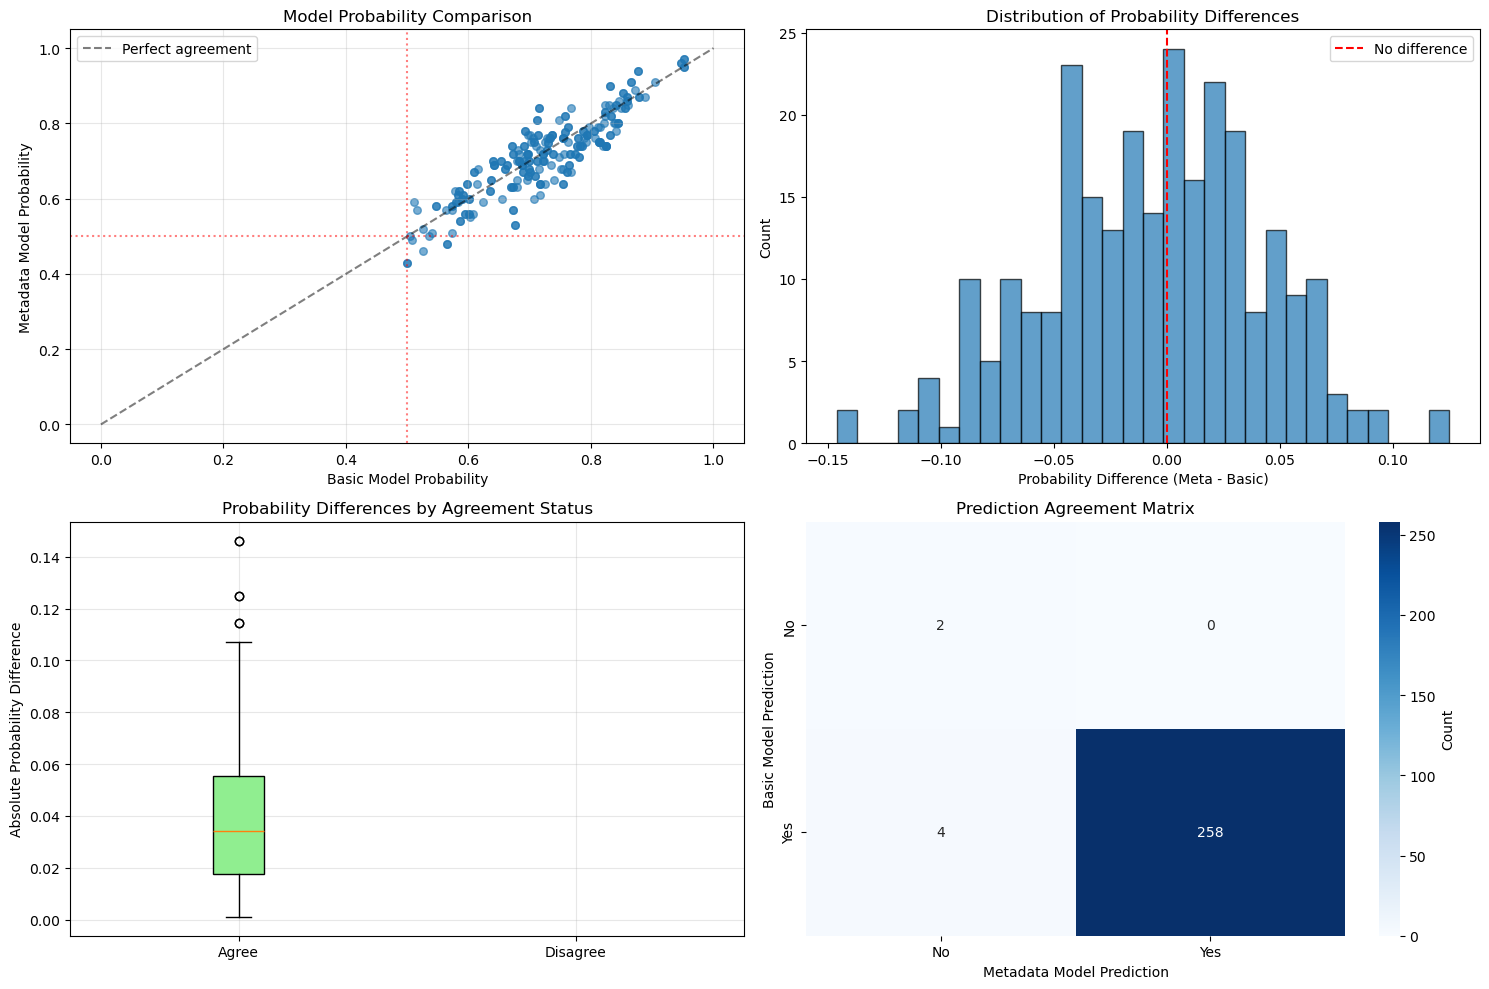

Entry_ID,SMILES,Basic_Prob,Meta_Prob,Difference,Basic_Says,Meta_Says,Agreement
LCC_EPIM_105,CC(C)(C)OC(N(CCCC1)[C@@H]1c(cc1)ccc1C(O)=O)=O,0.676,0.530,-0.146,Yes,Yes,✓ Agree
LCC_EPIM_106,CC(C)(C)OC(N(CCCC1)[C@H]1c(cc1)ccc1C(O)=O)=O,0.676,0.530,-0.146,Yes,Yes,✓ Agree
LCC_EPIM_246,O=C([C@@H]1N(C(OC(C)(C)C)=O)CC[C@H](C2=CC=CC=C2)C1)OC,0.715,0.840,+0.125,Yes,Yes,✓ Agree
LCC_EPIM_247,O=C([C@H]1N(C(OC(C)(C)C)=O)CC[C@@H](C2=CC=CC=C2)C1)OC,0.715,0.840,+0.125,Yes,Yes,✓ Agree
LCC_EPIM_018,Nc1ccc([C@H]2CNCCC2)cc1.Cl.Cl,0.754,0.640,-0.114,Yes,Yes,✓ Agree
LCC_EPIM_019,Nc1ccc([C@@H]2CNCCC2)cc1.Cl.Cl,0.754,0.640,-0.114,Yes,Yes,✓ Agree
LCC_EPIM_006,Nc1ccc([C@H]2CNCCC2)cc1,0.707,0.600,-0.107,Yes,Yes,✓ Agree
LCC_EPIM_199,CC(C)(C)OC(N(CCC1)[C@@H]1c1cc(C(O)=O)ccc1)=O,0.717,0.610,-0.107,Yes,Yes,✓ Agree
LCC_EPIM_103,CC(C)(C)OC(N(CCCC1)[C@@H]1c1cc(C(O)=O)ccc1)=O,0.673,0.570,-0.103,Yes,Yes,✓ Agree
LCC_EPIM_104,CC(C)(C)OC(N(CCCC1)[C@H]1c1cc(C(O)=O)ccc1)=O,0.673,0.570,-0.103,Yes,Yes,✓ Agree



🔍 Compounds with Largest Probability Differences:
  LCC_EPIM_105: Basic=0.676, Meta=0.530, Diff=-0.146
  LCC_EPIM_106: Basic=0.676, Meta=0.530, Diff=-0.146
  LCC_EPIM_246: Basic=0.715, Meta=0.840, Diff=+0.125
  LCC_EPIM_247: Basic=0.715, Meta=0.840, Diff=+0.125
  LCC_EPIM_018: Basic=0.754, Meta=0.640, Diff=-0.114
  LCC_EPIM_019: Basic=0.754, Meta=0.640, Diff=-0.114
  LCC_EPIM_006: Basic=0.707, Meta=0.600, Diff=-0.107
  LCC_EPIM_199: Basic=0.717, Meta=0.610, Diff=-0.107
  LCC_EPIM_103: Basic=0.673, Meta=0.570, Diff=-0.103
  LCC_EPIM_104: Basic=0.673, Meta=0.570, Diff=-0.103


In [ ]:
# %% Cell 6: Compare Basic Features vs Pre-Reaction Metadata Model Predictions

# Load both prediction files
try:
    basic_df = pd.read_csv("epimerization_predictions_basic.csv")
    meta_df = pd.read_csv("epimerization_predictions_metadata.csv")
except FileNotFoundError:
    print("❌ Error: Please run both Cell 3 (Basic) and Cell 5 (Metadata) first!")
    raise

# Load original data for SMILES
novel = pd.read_csv(
    r"M:\EPSRC Internship 2025\Project\Data\Novel\Data\Copy of Epimerisation - novel compounds to test.csv"
)
novel.rename(columns={novel.columns[0]: 'Entry_ID', novel.columns[1]: 'smi_start'}, inplace=True)

# Merge all data
comparison = pd.merge(basic_df, meta_df, on="Entry_ID", suffixes=("_basic", "_meta"))
comparison = pd.merge(comparison, novel[["Entry_ID", "smi_start"]], on="Entry_ID")

# Filter to epimerizable compounds only
epi_comparison = comparison[comparison["Epimerizes_basic"] != "N/A"].copy()

# Calculate differences and agreement
epi_comparison["Prob_Difference"] = epi_comparison["Epimerization_Probability_meta"] - epi_comparison["Epimerization_Probability_basic"]
epi_comparison["Abs_Difference"] = abs(epi_comparison["Prob_Difference"])
epi_comparison["Agreement"] = epi_comparison["Epimerizes_basic"] == epi_comparison["Epimerizes_meta"]

# Statistics
print("📊 Model Comparison Statistics:")
print(f"  Total epimerizable compounds: {len(epi_comparison)}")
print(f"  Agreement on Yes/No prediction: {epi_comparison['Agreement'].sum()}/{len(epi_comparison)} ({100*epi_comparison['Agreement'].mean():.1f}%)")
print(f"  Mean probability difference (meta - basic): {epi_comparison['Prob_Difference'].mean():.4f}")
print(f"  Mean absolute difference: {epi_comparison['Abs_Difference'].mean():.4f}")
print(f"  Max absolute difference: {epi_comparison['Abs_Difference'].max():.4f}")

# Find disagreements
disagreements = epi_comparison[~epi_comparison["Agreement"]]
print(f"\n  Disagreements: {len(disagreements)} compounds")
if len(disagreements) > 0:
    print(f"    - Basic says Yes, Metadata says No: {((disagreements['Epimerizes_basic'] == 'Yes') & (disagreements['Epimerizes_meta'] == 'No')).sum()}")
    print(f"    - Basic says No, Metadata says Yes: {((disagreements['Epimerizes_basic'] == 'No') & (disagreements['Epimerizes_meta'] == 'Yes')).sum()}")

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot of probabilities
ax1.scatter(epi_comparison["Epimerization_Probability_basic"], 
           epi_comparison["Epimerization_Probability_meta"], 
           alpha=0.6, s=30)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect agreement')
ax1.axhline(0.5, color='red', linestyle=':', alpha=0.5)
ax1.axvline(0.5, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Basic Model Probability')
ax1.set_ylabel('Metadata Model Probability')
ax1.set_title('Model Probability Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram of differences
ax2.hist(epi_comparison["Prob_Difference"], bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', label='No difference')
ax2.set_xlabel('Probability Difference (Meta - Basic)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Probability Differences')
ax2.legend()

# 3. Box plot by agreement
agreement_data = [
    epi_comparison[epi_comparison["Agreement"]]["Abs_Difference"],
    epi_comparison[~epi_comparison["Agreement"]]["Abs_Difference"]
]
bp = ax3.boxplot(agreement_data, labels=['Agree', 'Disagree'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
ax3.set_ylabel('Absolute Probability Difference')
ax3.set_title('Probability Differences by Agreement Status')
ax3.grid(True, alpha=0.3)

# 4. Confusion matrix style plot
confusion_data = pd.crosstab(epi_comparison["Epimerizes_basic"], 
                            epi_comparison["Epimerizes_meta"])
sns.heatmap(confusion_data, annot=True, fmt='d', cmap='Blues', ax=ax4, 
            cbar_kws={'label': 'Count'})
ax4.set_xlabel('Metadata Model Prediction')
ax4.set_ylabel('Basic Model Prediction')
ax4.set_title('Prediction Agreement Matrix')

plt.tight_layout()
plt.show()

# Create detailed comparison table
comparison_display = epi_comparison.copy()
comparison_display = comparison_display.sort_values("Abs_Difference", ascending=False)

# Format for display with NaN handling
def format_probability_compare(row):
    basic = row["Epimerization_Probability_basic"]
    meta = row["Epimerization_Probability_meta"]
    
    # Handle NaN values
    if pd.isna(basic) or pd.isna(meta):
        return ('<span style="color: #95a5a6;">N/A</span>',
                '<span style="color: #95a5a6;">N/A</span>',
                '<span style="color: #95a5a6;">N/A</span>')
    
    diff = meta - basic
    
    basic_color = f"rgb({int(255*basic)}, {int(255*(1-basic))}, 0)"
    meta_color = f"rgb({int(255*meta)}, {int(255*(1-meta))}, 0)"
    
    if abs(diff) < 0.1:
        diff_color = "#27ae60"  # Green for small difference
    elif abs(diff) < 0.3:
        diff_color = "#f39c12"  # Orange for medium difference
    else:
        diff_color = "#e74c3c"  # Red for large difference
    
    return (f'<span style="color: {basic_color}; font-weight: bold;">{basic:.3f}</span>',
            f'<span style="color: {meta_color}; font-weight: bold;">{meta:.3f}</span>',
            f'<span style="color: {diff_color}; font-weight: bold;">{diff:+.3f}</span>')

def format_agreement(agree):
    if agree:
        return '<span style="color: #27ae60; font-weight: bold;">✓ Agree</span>'
    else:
        return '<span style="color: #e74c3c; font-weight: bold;">✗ Disagree</span>'

# Create display dataframe
display_df = pd.DataFrame({
    "Entry_ID": comparison_display["Entry_ID"],
    "SMILES": comparison_display["smi_start"].apply(lambda x: f'<span style="font-family: monospace; font-size: 10px;">{x}</span>'),
    "Basic_Prob": "",
    "Meta_Prob": "",
    "Difference": "",
    "Basic_Says": comparison_display["Epimerizes_basic"],
    "Meta_Says": comparison_display["Epimerizes_meta"],
    "Agreement": comparison_display["Agreement"].apply(format_agreement)
})

# Apply probability formatting
for idx, row in comparison_display.iterrows():
    basic_fmt, meta_fmt, diff_fmt = format_probability_compare(row)
    display_df.loc[idx, "Basic_Prob"] = basic_fmt
    display_df.loc[idx, "Meta_Prob"] = meta_fmt
    display_df.loc[idx, "Difference"] = diff_fmt

# Color code Yes/No predictions
display_df["Basic_Says"] = display_df["Basic_Says"].map({
    "Yes": '<span style="color: #e74c3c; font-weight: bold;">Yes</span>',
    "No": '<span style="color: #27ae60; font-weight: bold;">No</span>'
})
display_df["Meta_Says"] = display_df["Meta_Says"].map({
    "Yes": '<span style="color: #e74c3c; font-weight: bold;">Yes</span>',
    "No": '<span style="color: #27ae60; font-weight: bold;">No</span>'
})

# Create HTML
html_table = display_df.to_html(index=False, escape=False)

styled_html = f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif;">
    <h2 style="color: #2c3e50; margin-bottom: 10px;">
        Model Comparison: Basic Features vs Pre-Reaction Metadata
    </h2>
    <div style="background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin-bottom: 15px;">
        <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px;">
            <div style="text-align: center; padding: 10px; background-color: white; border-radius: 5px; border: 1px solid #ddd;">
                <div style="font-size: 20px; font-weight: bold; color: #3498db;">{len(epi_comparison)}</div>
                <div style="color: #7f8c8d; font-size: 12px;">Total Compounds</div>
            </div>
            <div style="text-align: center; padding: 10px; background-color: white; border-radius: 5px; border: 1px solid #ddd;">
                <div style="font-size: 20px; font-weight: bold; color: #27ae60;">{epi_comparison['Agreement'].sum()}</div>
                <div style="color: #7f8c8d; font-size: 12px;">Agreements ({100*epi_comparison['Agreement'].mean():.1f}%)</div>
            </div>
            <div style="text-align: center; padding: 10px; background-color: white; border-radius: 5px; border: 1px solid #ddd;">
                <div style="font-size: 20px; font-weight: bold; color: #e74c3c;">{len(disagreements)}</div>
                <div style="color: #7f8c8d; font-size: 12px;">Disagreements</div>
            </div>
            <div style="text-align: center; padding: 10px; background-color: white; border-radius: 5px; border: 1px solid #ddd;">
                <div style="font-size: 20px; font-weight: bold; color: #f39c12;">{epi_comparison['Abs_Difference'].mean():.3f}</div>
                <div style="color: #7f8c8d; font-size: 12px;">Mean |Difference|</div>
            </div>
        </div>
    </div>
    <div style="max-height: 600px; overflow-y: auto; border: 2px solid #9b59b6; border-radius: 5px;">
        <style>
            .compare-table {{
                border-collapse: collapse;
                width: 100%;
                font-size: 13px;
            }}
            .compare-table th {{
                background-color: #9b59b6;
                color: white;
                padding: 12px 8px;
                position: sticky;
                top: 0;
                z-index: 10;
                text-align: left;
                font-weight: 600;
            }}
            .compare-table td {{
                padding: 8px;
                border-bottom: 1px solid #ecf0f1;
            }}
            .compare-table tr:hover {{
                background-color: #f5f3ff;
            }}
            .compare-table tr:nth-child(even) {{
                background-color: #f8f9fa;
            }}
        </style>
        <table class="compare-table">
            {html_table.replace('<table', '').replace('</table>', '')}
        </table>
    </div>
    <p style="margin-top: 10px; font-size: 12px; color: #7f8c8d;">
        <em>Sorted by absolute difference. Difference = Metadata - Basic. 
        Green difference = <0.1, Orange = 0.1-0.3, Red = >0.3</em>
    </p>
</div>
"""

display(HTML(styled_html))

# Highlight compounds with largest disagreements
print("\n🔍 Compounds with Largest Probability Differences:")
top_diffs = comparison_display.nlargest(10, "Abs_Difference")[["Entry_ID", "Epimerization_Probability_basic", 
                                                                "Epimerization_Probability_meta", "Prob_Difference"]]
for _, row in top_diffs.iterrows():
    print(f"  {row['Entry_ID']}: Basic={row['Epimerization_Probability_basic']:.3f}, "
          f"Meta={row['Epimerization_Probability_meta']:.3f}, Diff={row['Prob_Difference']:+.3f}")

